# Function 3 – Comparison at incumbent (Week 9)

Recreate the graphing and visualisation from [week 8 function 3 next evaluation](../week8/function3_next_evaluation.ipynb), loading **week 8 data** and **focusing on comparing the two results at the incumbent**: the first observation (where that point first appeared—**Initial data** or a specific week) and the Week 8 observation at the same point.

In [12]:
import numpy as np
from pathlib import Path
import sys
sys.path.insert(0, str(Path().resolve().parent.parent))
from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_3d_scatter_with_distribution,
)

base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')
week7_dir = Path('../../data/week7')
week8_dir = Path('../../data/week8')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')
week7_data = _load_latest_week_data(week7_dir, 'Week 7')

function_name = 'function_3'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']
week7_input = week7_data[function_name]['input']
week7_output = week7_data[function_name]['output']

combined_inputs = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
    week7_input.reshape(1, -1),
])
combined_outputs = np.concatenate([
    original_outputs,
    np.array([week1_output, week2_output, week3_output, week4_output, week5_output, week6_output, week7_output]),
])

best_idx = np.argmax(combined_outputs)
incumbent_input = combined_inputs[best_idx]
incumbent_output_first = float(combined_outputs[best_idx])

n_initial = len(original_outputs)
if best_idx < n_initial:
    incumbent_source = 'Initial data'
else:
    week_num = best_idx - n_initial + 1
    incumbent_source = f'Week {week_num}'

print(f'Incumbent input (best-performing configuration): {incumbent_input}')
print(f'Incumbent output (first observation, from {incumbent_source}): {incumbent_output_first:.6f}')

Incumbent input (best-performing configuration): [0.49258141 0.61159319 0.34017639]
Incumbent output (first observation, from Initial data): -0.034835


In [13]:
def load_all_week_blocks(week_dir):
    """Load all evaluation blocks from a week's inputs.txt and outputs.txt."""
    week_dir = Path(week_dir)
    inputs_path = week_dir / 'inputs.txt'
    outputs_path = week_dir / 'outputs.txt'
    
    def split_blocks(lines):
        blocks = []
        current = []
        for line in lines:
            if line.strip().startswith('[') and current:
                blocks.append(''.join(current))
                current = [line]
            else:
                current.append(line)
        if current:
            blocks.append(''.join(current))
        return [b.strip() for b in blocks if b.strip()]
    
    with open(inputs_path, 'r') as f:
        input_blocks = split_blocks(f.readlines())
    with open(outputs_path, 'r') as f:
        output_blocks = split_blocks(f.readlines())
    
    results = []
    for in_block, out_block in zip(input_blocks, output_blocks):
        try:
            inputs_list = eval(in_block, {'array': np.array, 'np': np})
            outputs_list = eval(out_block, {'np': np, 'np.float64': np.float64})
            results.append((inputs_list, outputs_list))
        except (SyntaxError, Exception):
            continue
    return results

week8_blocks = load_all_week_blocks(week8_dir)
function_3_idx = 2  # function_3 is the 3rd function (0-based)
rerun_output = None
for inputs_list, outputs_list in week8_blocks:
    inp_f3 = np.array(inputs_list[function_3_idx])
    if inp_f3.ndim == 0:
        continue
    if np.allclose(inp_f3, incumbent_input):
        out_f3 = np.array(outputs_list[function_3_idx])
        rerun_output = float(np.squeeze(out_f3))
        break

if rerun_output is None:
    raise ValueError('Could not find Week 8 evaluation at incumbent in data/week8. Check inputs.txt.')

print(f'Week 8 at same input (incumbent): output = {rerun_output:.6f}')
print(f'Difference (Week 8 − first):   {rerun_output - incumbent_output_first:.6f}')

Week 8 at same input (incumbent): output = -0.045369
Difference (Week 8 − first):   -0.010533


## Visualisation: Weeks 1–8

Same style as week 8: 3D scatter of combined data with weekly points highlighted, and output distribution. Week 8 is included so the distribution shows **both** the first observation at the incumbent and the Week 8 evaluation at the same point.

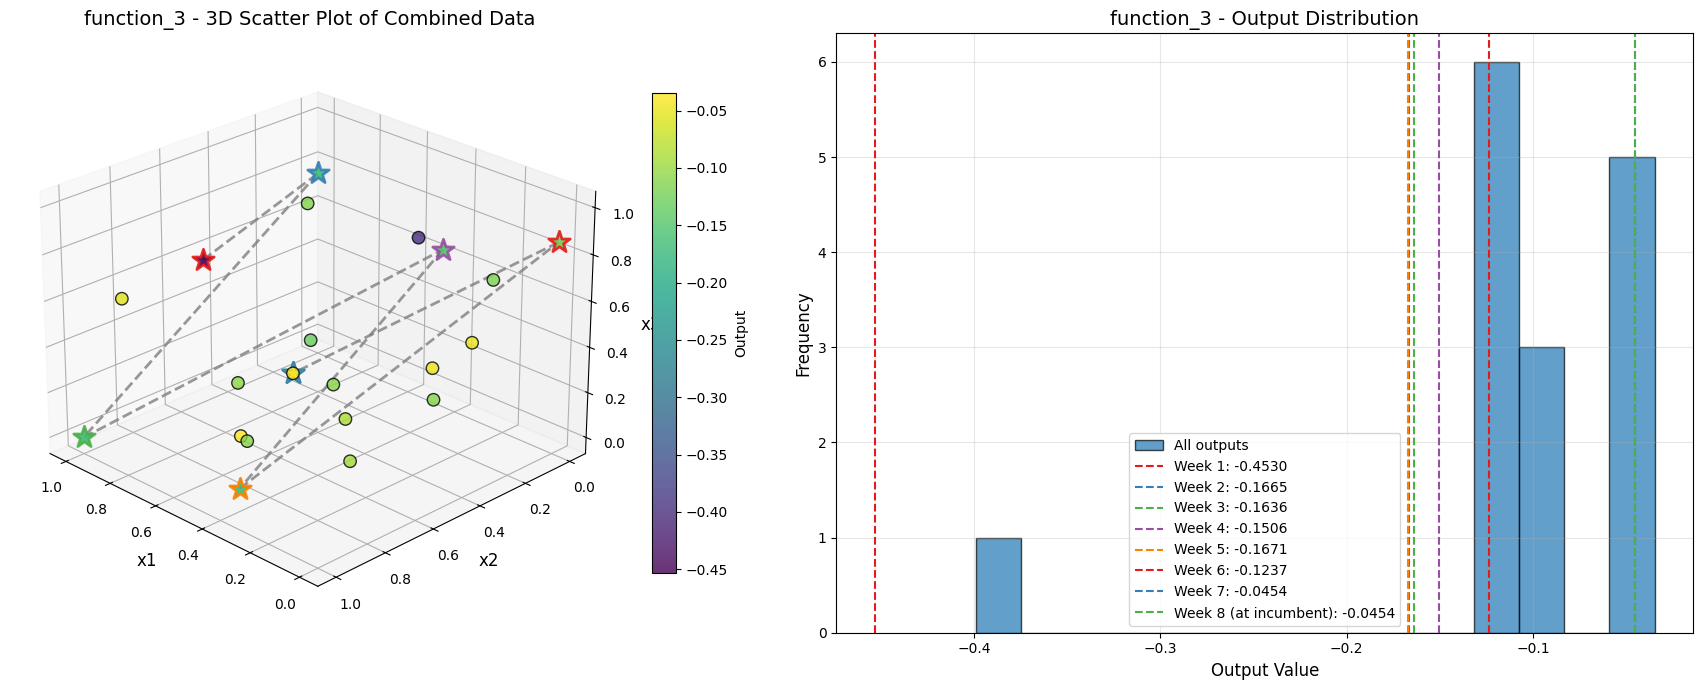

In [14]:
weekly_points = [
    (week1_input, week1_output, 'Week 1'),
    (week2_input, week2_output, 'Week 2'),
    (week3_input, week3_output, 'Week 3'),
    (week4_input, week4_output, 'Week 4'),
    (week5_input, week5_output, 'Week 5'),
    (week6_input, week6_output, 'Week 6'),
    (week7_input, week7_output, 'Week 7'),
    (incumbent_input, rerun_output, 'Week 8 (at incumbent)'),
]

plot_3d_scatter_with_distribution(
    original_inputs,
    original_outputs,
    incumbent_input,
    rerun_output,
    function_name,
    weekly_points=weekly_points,
    connect_points=True,
)

## Comparison: first observation vs Week 8 at incumbent

The **same input** (incumbent) was evaluated in two different weeks: first when that point gave the maximum (from Initial data or an earlier week—see the first cell for which) and again in Week 8 (normal Bayesian). Below we compare the two outputs directly.

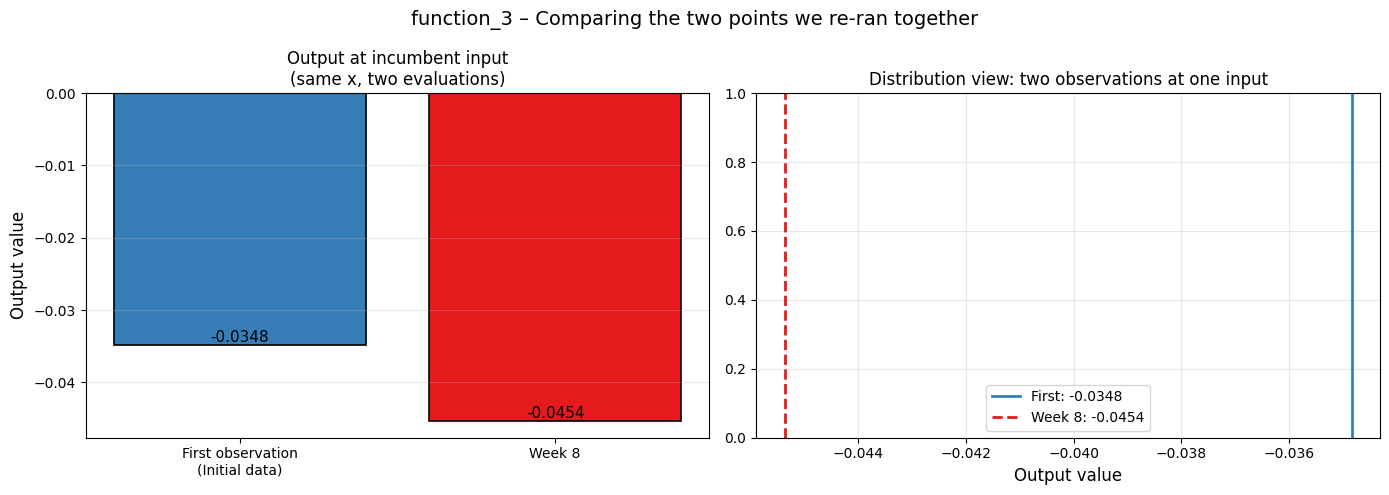

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f'First observation\n({incumbent_source})', 'Week 8']
values = [incumbent_output_first, rerun_output]
colors = ['#377eb8', '#e41a1c']

axes[0].bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('Output value', fontsize=12)
axes[0].set_title('Output at incumbent input\n(same x, two evaluations)', fontsize=12)
axes[0].grid(True, axis='y', alpha=0.3)
for i, (lbl, val) in enumerate(zip(labels, values)):
    axes[0].text(i, val, f'{val:.4f}', ha='center', va='bottom', fontsize=11)

axes[1].axvline(incumbent_output_first, color=colors[0], linestyle='-', linewidth=2, label=f'First: {incumbent_output_first:.4f}')
axes[1].axvline(rerun_output, color=colors[1], linestyle='--', linewidth=2, label=f'Week 8: {rerun_output:.4f}')
axes[1].set_xlabel('Output value', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_title('Distribution view: two observations at one input', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{function_name} – Comparing the two points we re-ran together', fontsize=14)
plt.tight_layout()
plt.show()

SUMMARY - it is noisy, but that point is still the maximum, so we should be exploring around there. 

## Bayesian optimisation: suggest next point (explore around incumbent)

We include **all data so far** (initial + weeks 1–8) so the noise-aware GP sees both observations at the incumbent. Then we run the same noise-aware BO as in [week 6 function 3](../week6/function3_bayesian_validation.ipynb) to suggest the next point for exploration around that maximum.

In [16]:
import json
from scripts.bayesian_optimisation import BayesianOptimizationForNoise

# Observed data: initial + weeks 1–8 (GP sees both observations at incumbent)
X_observed = np.vstack([combined_inputs, incumbent_input.reshape(1, -1)])
y_observed = np.concatenate([combined_outputs, np.array([rerun_output])])

n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

bo = BayesianOptimizationForNoise(bounds=bounds, n_initial=0, random_state=42)
bo.fit(X_observed, y_observed)

next_point = bo.suggest_next_point(beta=0.5)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.5)[0]
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print("=" * 60)
print("FUNCTION 3 – NOISE-AWARE BO (data: initial + weeks 1–8)")
print("=" * 60)
print(f"Observed points: {X_observed.shape[0]} (incl. Week 8 at incumbent)")
print(f"Suggested next point: {formatted_point}")
print(f"UCB (β=0.5) at next point: {ucb_value:.6f}")
print("=" * 60)

result_json = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "bayesian_optimization_for_noise",
}
output_path = Path("results/function3_next_point.json")
output_path.parent.mkdir(exist_ok=True)
with open(output_path, "w") as f:
    json.dump(result_json, f, indent=2)
print(f"\nResult saved to: {output_path}")

FUNCTION 3 – NOISE-AWARE BO (data: initial + weeks 1–8)
Observed points: 23 (incl. Week 8 at incumbent)
Suggested next point: 0.627298-0.576795-0.510590
UCB (β=0.5) at next point: -0.014937

Result saved to: results/function3_next_point.json


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Inputs/Outputs comparison table (Function 3)

Source, Input number, Output value, Distance to maximum input, Summary of progress. Proposed week 8 row uses the BO-suggested next point and UCB as estimated output.

In [17]:
import importlib
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

n_initial = original_inputs.shape[0]
table = make_inputs_outputs_table(
    X_observed, y_observed, n_initial,
    x_proposed=next_point,
    y_proposed=float(ucb_value),
)
display(table)

,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,-0.112122,4.278888e-01,Initial
1,initial,2,-0.087963,2.614917e-01,Initial
2,initial,3,-0.111415,2.738937e-01,Initial
3,initial,4,-0.034835,0.000000e+00,Initial
4,initial,5,-0.048008,5.435773e-01,Initial
5,initial,6,-0.110621,3.679492e-01,Initial
6,initial,7,-0.398926,7.543024e-01,Initial
7,initial,8,-0.113869,6.366350e-01,Initial
8,initial,9,-0.131461,4.299309e-01,Initial
9,initial,10,-0.094190,3.841026e-01,Initial


## Slice plots at incumbent (GP mean, std, UCB)

Fix one input at the incumbent best and plot the GP **mean**, **std**, and **acquisition (UCB)** over the other two dimensions. The suggested next point should lie in a high-acquisition region near the incumbent (exploring around that maximum).

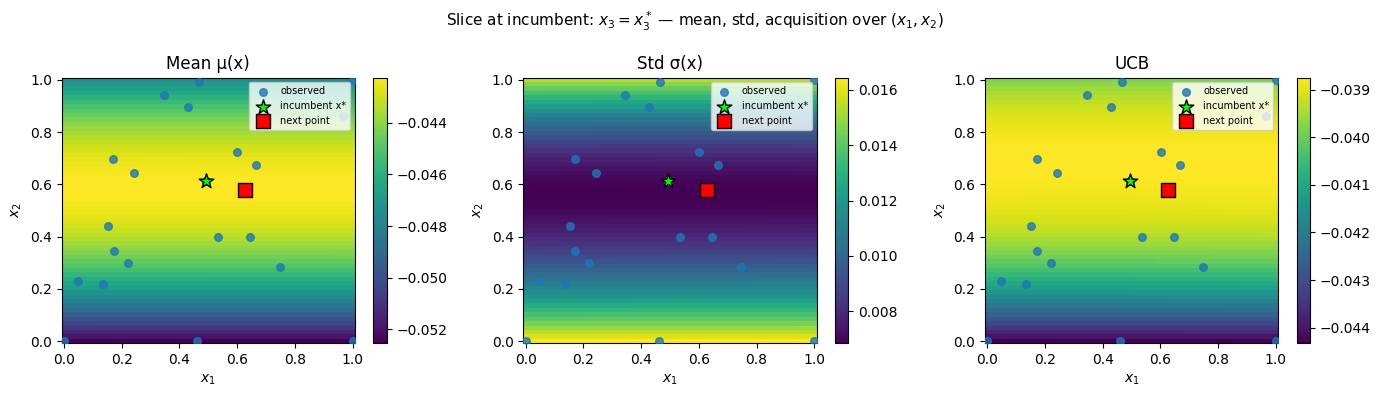

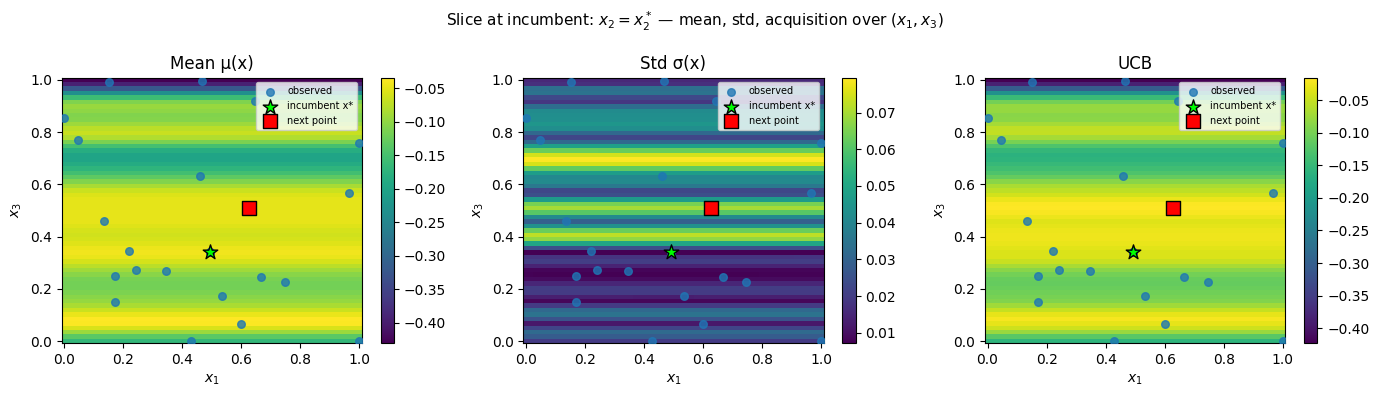

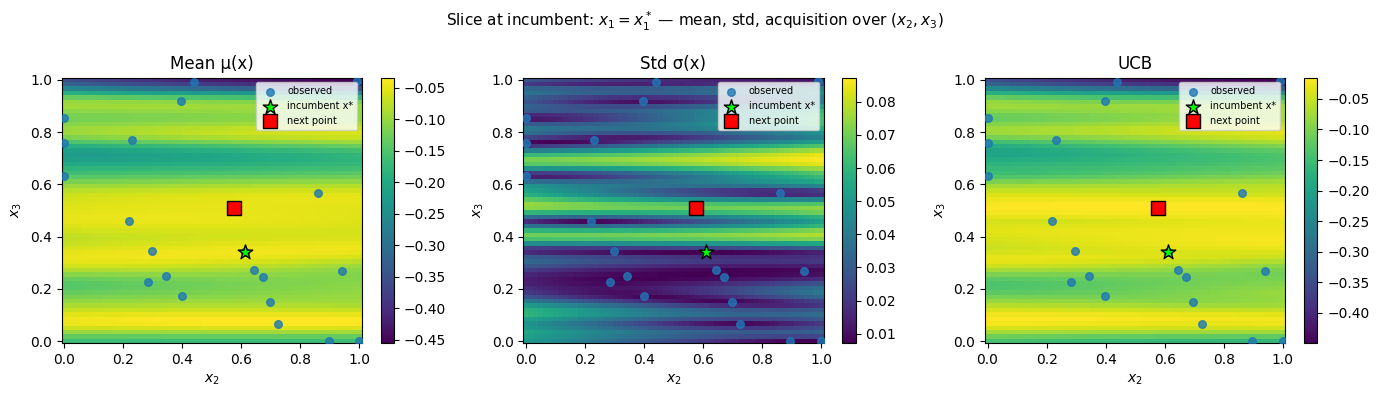

In [11]:
import matplotlib.pyplot as plt

x_star = X_observed[np.argmax(y_observed)]
beta_ucb = 0.5
ngrid = 60
bounds_arr = np.array(bounds)

def eval_slice(bo, x_star, varying_dims, fixed_dim, ngrid=60):
    """Build grid on 2D slice (fixed_dim = x_star[fixed_dim]), return mesh + mean, std, acquisition."""
    d0, d1 = varying_dims
    lo0, hi0 = bounds_arr[d0, 0], bounds_arr[d0, 1]
    lo1, hi1 = bounds_arr[d1, 0], bounds_arr[d1, 1]
    g0 = np.linspace(lo0, hi0, ngrid)
    g1 = np.linspace(lo1, hi1, ngrid)
    gg0, gg1 = np.meshgrid(g0, g1)
    n_pts = gg0.size
    X = np.zeros((n_pts, 3))
    X[:, d0] = gg0.ravel()
    X[:, d1] = gg1.ravel()
    X[:, fixed_dim] = x_star[fixed_dim]
    mean, std = bo.predict(X)
    ucb = bo.acquisition_ucb(X, beta=beta_ucb)
    return gg0, gg1, mean.reshape(gg0.shape), std.reshape(gg0.shape), ucb.reshape(gg0.shape)

def plot_slice(ax_mean, ax_std, ax_acq, gg0, gg1, mean, std, ucb,
               X_obs, x_star, next_pt, varying_dims):
    d0, d1 = varying_dims
    for ax, data, label in [(ax_mean, mean, "Mean μ(x)"), (ax_std, std, "Std σ(x)"), (ax_acq, ucb, "UCB")]:
        im = ax.pcolormesh(gg0, gg1, data, shading="auto")
        plt.colorbar(im, ax=ax)
        ax.set_xlabel(f"$x_{d0+1}$")
        ax.set_ylabel(f"$x_{d1+1}$")
        ax.set_title(label)
    for ax in (ax_mean, ax_std, ax_acq):
        ax.scatter(X_obs[:, d0], X_obs[:, d1], c="tab:blue", s=30, alpha=0.8, label="observed", zorder=3)
        ax.scatter(x_star[d0], x_star[d1], c="lime", s=120, marker="*", edgecolors="black", label="incumbent x*", zorder=4)
        ax.scatter(next_pt[d0], next_pt[d1], c="red", s=100, marker="s", edgecolors="black", label="next point", zorder=4)
        ax.legend(loc="upper right", fontsize=7)

# Slice at x3 = x3*, over (x1, x2)
gg0_12, gg1_12, mean_12, std_12, ucb_12 = eval_slice(bo, x_star, (0, 1), 2, ngrid)
fig1, (ax1m, ax1s, ax1u) = plt.subplots(1, 3, figsize=(14, 4))
plot_slice(ax1m, ax1s, ax1u, gg0_12, gg1_12, mean_12, std_12, ucb_12,
           X_observed, x_star, next_point, (0, 1))
fig1.suptitle("Slice at incumbent: $x_3 = x_3^*$ — mean, std, acquisition over $(x_1, x_2)$", fontsize=11)
plt.tight_layout()
plt.show()

# Slice at x2 = x2*, over (x1, x3)
gg0_13, gg1_13, mean_13, std_13, ucb_13 = eval_slice(bo, x_star, (0, 2), 1, ngrid)
fig2, (ax2m, ax2s, ax2u) = plt.subplots(1, 3, figsize=(14, 4))
plot_slice(ax2m, ax2s, ax2u, gg0_13, gg1_13, mean_13, std_13, ucb_13,
           X_observed, x_star, next_point, (0, 2))
fig2.suptitle("Slice at incumbent: $x_2 = x_2^*$ — mean, std, acquisition over $(x_1, x_3)$", fontsize=11)
plt.tight_layout()
plt.show()

# Slice at x1 = x1*, over (x2, x3)
gg0_23, gg1_23, mean_23, std_23, ucb_23 = eval_slice(bo, x_star, (1, 2), 0, ngrid)
fig3, (ax3m, ax3s, ax3u) = plt.subplots(1, 3, figsize=(14, 4))
plot_slice(ax3m, ax3s, ax3u, gg0_23, gg1_23, mean_23, std_23, ucb_23,
           X_observed, x_star, next_point, (1, 2))
fig3.suptitle("Slice at incumbent: $x_1 = x_1^*$ — mean, std, acquisition over $(x_2, x_3)$", fontsize=11)
plt.tight_layout()
plt.show()